#                                                     **Federated Machine Learning for Predicting Animal-to-Human Zoonotic Disease Outbreaks EDA**                                                     

## Load Farm Dataset & Initial Inspection
## Objective

- Understand dataset structure

- Verify data types

- Check class distribution

- Ensure suitability for federated learning

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skewnorm
import os

np.random.seed(42)

# ===============================
# Client features with realistic ranges
# ===============================
CLIENT_FEATURES_RANGES = {
    'Farm': {
        'Animal_Population': (50, 200),
        'Animal_Mortality': (0, 10),
        'Vaccination_Rate': (0.7, 1.0),
        'Temperature': (15, 40),  # Celsius
        'Humidity': (30, 90),     # %
        'Rainfall': (0, 20),      # mm
        'Contact_Index': (0, 1)
    },
    'Hospital': {
        'Reported_Cases': (0, 50),
        'Mortality_Rate': (0, 0.1),
        'Symptom_Count': (0, 10),
        'Admissions': (0, 30),
        'Positivity_Rate': (0, 0.2),
        'Contact_Index': (0, 1)
    },
    'Wildlife': {
        'Species_Count': (1, 15),
        'Migration_Flag': (0, 1),
        'Habitat_Proximity': (0, 1),
        'Wildlife_Mortality': (0, 5),
        'Exposure_Score': (0, 1)
    }
}

# ===============================
# Synthetic Data Generator
# ===============================
def generate_realistic_data(feature_ranges, n_samples=15000, missing_frac=0.05, outlier_frac=0.02):
    X = pd.DataFrame()
    
    for f, (low, high) in feature_ranges.items():
        # Slight skew
        skewness = np.random.uniform(-2, 2)
        X[f] = skewnorm.rvs(a=skewness, loc=(low+high)/2, scale=(high-low)/6, size=n_samples)
        
        # Clip to realistic range
        X[f] = np.clip(X[f], low, high)
        
        # Missing values
        n_missing = int(missing_frac * n_samples)
        missing_idx = np.random.choice(n_samples, n_missing, replace=False)
        X.loc[missing_idx, f] = np.nan
        
        # Outliers
        n_outliers = int(outlier_frac * n_samples)
        outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
        X.loc[outlier_idx, f] = X.loc[outlier_idx, f] * np.random.uniform(1.5, 3)

    # Target generation: simple sum rule with quantiles
    score = X.fillna(X.mean()).sum(axis=1)
    y = np.where(score > score.quantile(0.66), 2,
         np.where(score > score.quantile(0.33), 1, 0))
    
    X['Target'] = y
    return X

# ===============================
# Save datasets locally
# ===============================


for client, ranges in CLIENT_FEATURES_RANGES.items():
    df = generate_realistic_data(ranges)
    file_path = f'{client}_data.csv'
    df.to_csv(file_path, index=False)
    print(f"{client} dataset saved: {file_path}")


Farm dataset saved: synthetic_data_realistic/Farm_data.csv
Hospital dataset saved: synthetic_data_realistic/Hospital_data.csv
Wildlife dataset saved: synthetic_data_realistic/Wildlife_data.csv


In [1]:
import pandas as pd # For Data Manipulation
import numpy as np # For Numerical Operations
import matplotlib.pyplot as plt # For Data Visualization
import seaborn as sns # For Statistical Data Visualization

# Load dataset
df = pd.read_csv("farm_data.csv")

# Basic inspection
print(df.shape) # Print the shape of the DataFrame
print(df.head()) # Print the first few rows of the DataFrame
print(df.info()) # Print summary information about the DataFrame


(15000, 8)
   Animal_Population  Animal_Mortality  Vaccination_Rate  Temperature  \
0         111.552347          6.731351               NaN    29.858701   
1         139.609878          3.619193          0.756529          NaN   
2         108.572897          5.453334               NaN    24.879479   
3         121.023948          1.918228          0.868019    32.421057   
4         138.769451          5.237049          0.769797    19.452406   

    Humidity   Rainfall  Contact_Index  Target  
0  46.697660   8.274343       0.339439       0  
1  64.050497   2.799500       0.499517       2  
2  50.891447  32.958769       0.567497       1  
3  53.977095   8.843257       0.509404       1  
4  62.653651  15.364472       0.077340       2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Animal_Population  14250 non-null  float64
 1  

- Dataset contains 15,000 rows

- All features are numerical

- One target column: Target

- Some missing values will be there

In [2]:
# Checking duplicates on full Dataset
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicates}")

Number of duplicate rows in the dataset: 0


In [3]:
# checking for null values
null_values = df.isnull().sum()
print("Null values in each column:")
print(null_values)


Null values in each column:
Animal_Population    750
Animal_Mortality     750
Vaccination_Rate     750
Temperature          750
Humidity             750
Rainfall             750
Contact_Index        750
Target                 0
dtype: int64


- Based one above execution we can clearly know how many null values will present in each column

## Target Variable Distribution

C:\Users\dayav\AppData\Local\Temp\ipykernel_11732\680680700.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Target", data=df, palette="viridis")


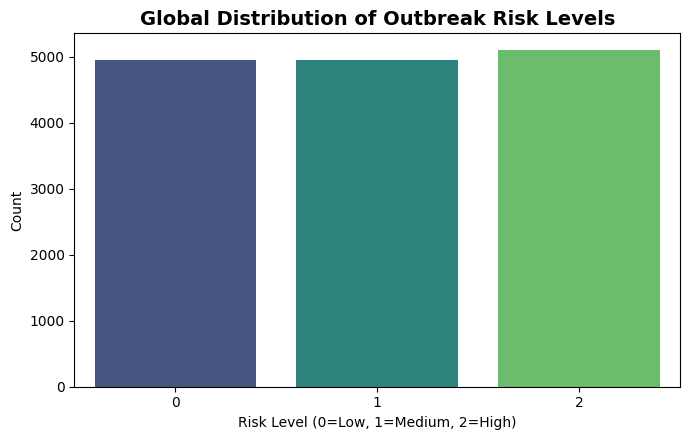

In [5]:
# Global Target Distribution
# =============================================================================
plt.figure(figsize=(7, 4.5))
sns.countplot(x="Target", data=df, palette="viridis")
plt.title("Global Distribution of Outbreak Risk Levels", fontsize=14, fontweight='bold')
plt.xlabel("Risk Level (0=Low, 1=Medium, 2=High)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

- So here our Target variable is Balenced

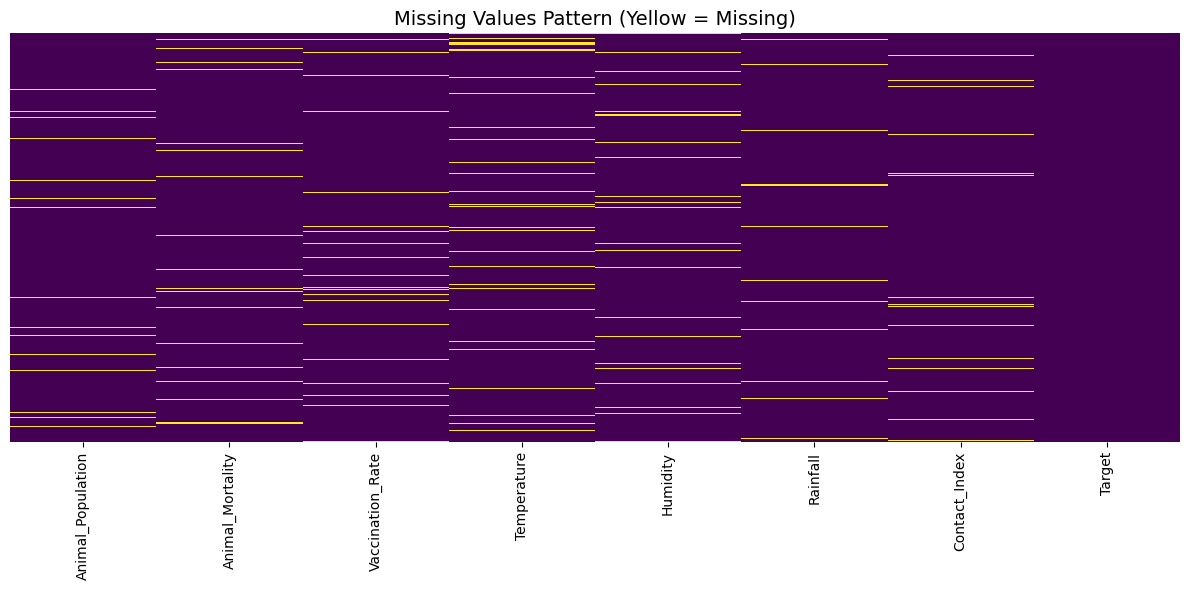

In [6]:
# =============================================================================
#  Missing Values Heatmap (whole dataset)
# =============================================================================
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Pattern (Yellow = Missing)", fontsize=14)
plt.tight_layout()
plt.show()

- Wherever the yellow lines is there all are missing values, Assume approximately 5% of missing values is there

# EDA per Client (Farm)
-------------------------

C:\Users\dayav\AppData\Local\Temp\ipykernel_11732\1343626852.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
C:\Users\dayav\AppData\Local\Temp\ipykernel_11732\1343626852.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
C:\Users\dayav\AppData\Local\Temp\ipykernel_11732\1343626852.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
C:\Users\dayav\A

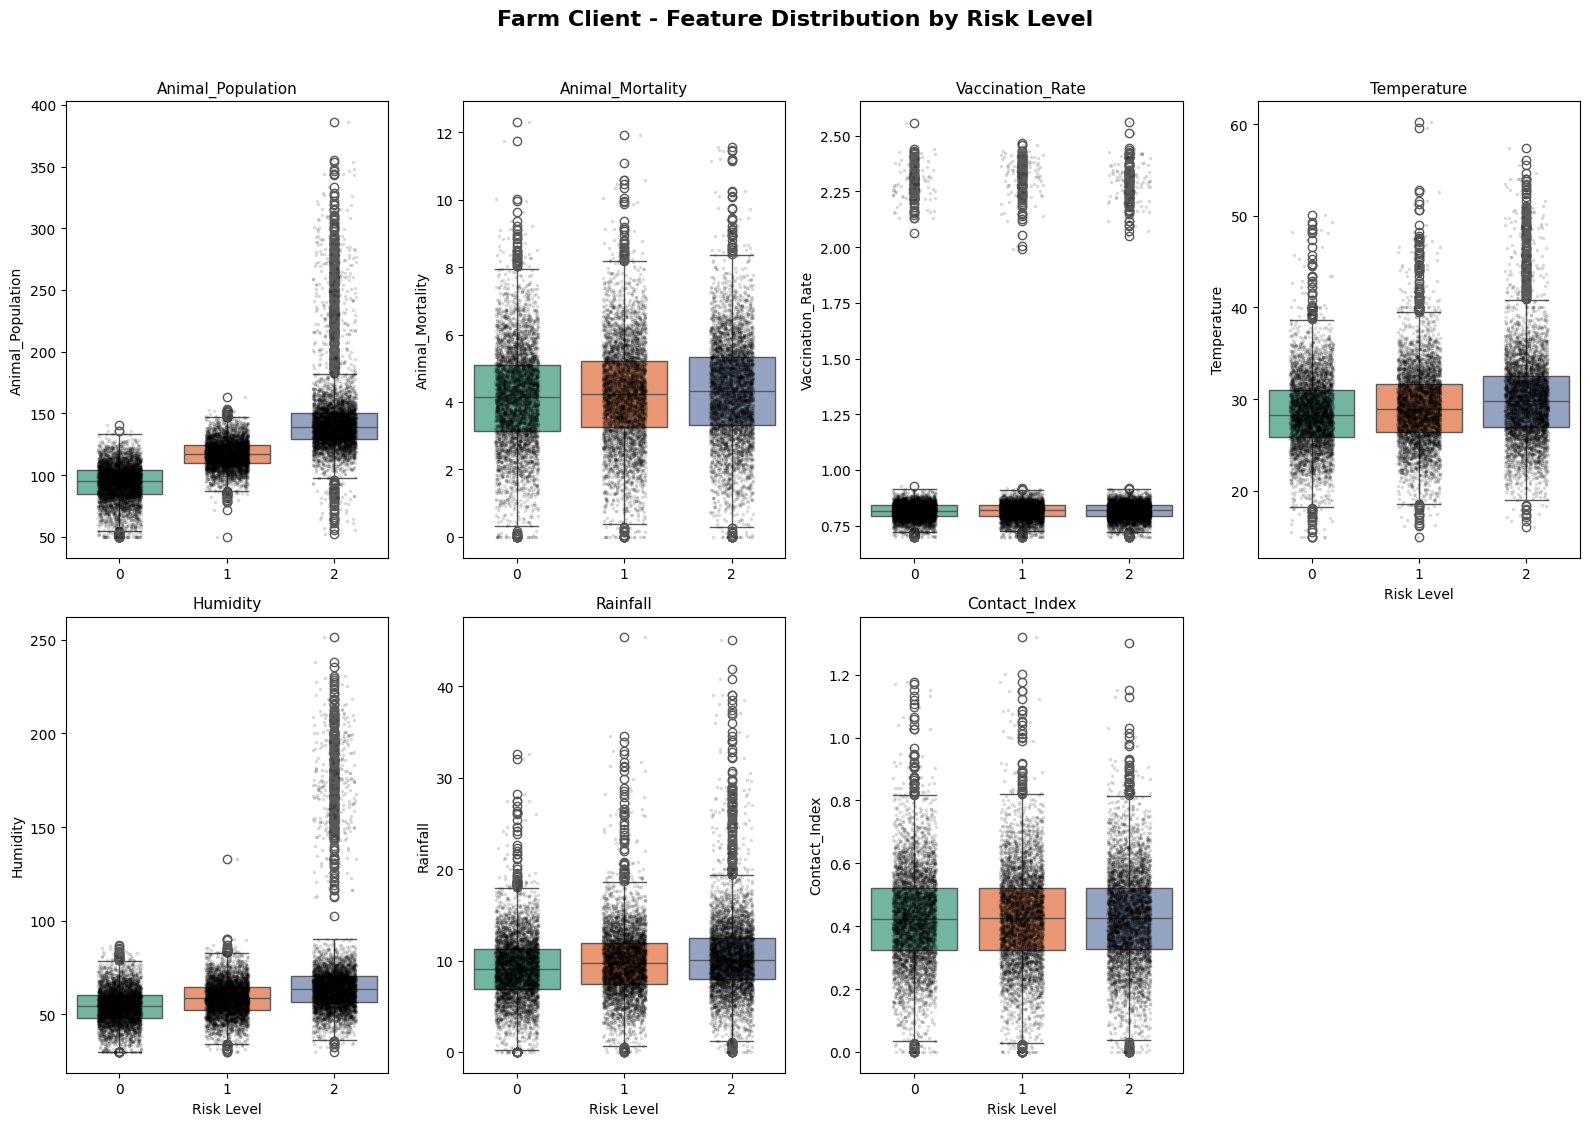

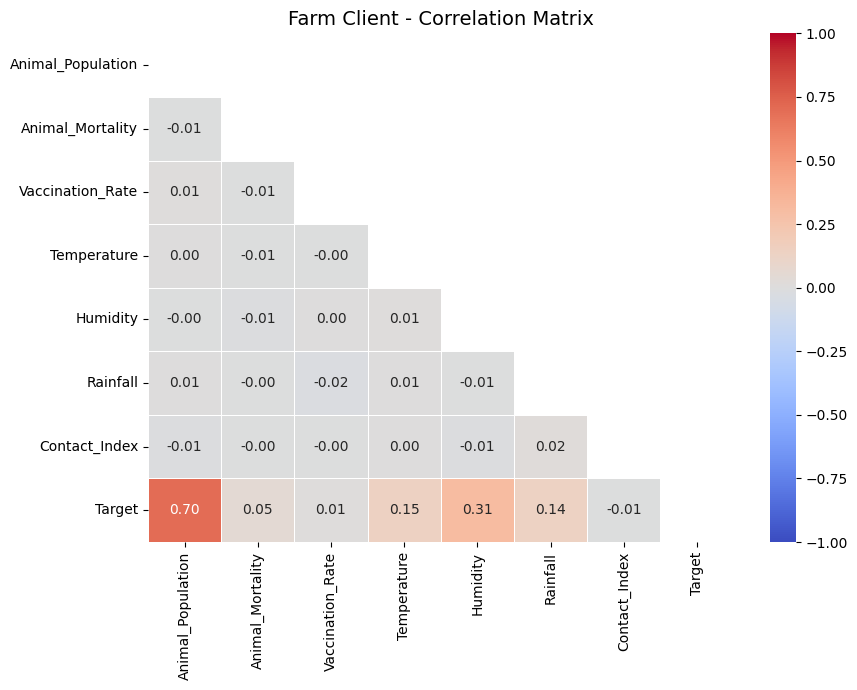

In [8]:
def plot_client_eda(client_df, client_name, figsize=(16, 12)):
    numeric_cols = client_df.select_dtypes(include=np.number).columns.tolist()
    if "Target" in numeric_cols:
        numeric_cols.remove("Target")
    
    n_cols = len(numeric_cols)
    n_rows = (n_cols + 3) // 4
    
    fig, axes = plt.subplots(n_rows, 4, figsize=figsize)
    axes = axes.flatten()
    
    # Boxplots + Violin + strip (for small n we skip strip)
    for i, col in enumerate(numeric_cols):
        sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
        sns.stripplot(x="Target", y=col, data=client_df, 
                      color='k', alpha=0.15, size=2.5, jitter=0.2, ax=axes[i])
        axes[i].set_title(f"{col}", fontsize=11)
        axes[i].set_xlabel("Risk Level" if i >= len(numeric_cols)-4 else "")
    
    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f"{client_name} - Feature Distribution by Risk Level", 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Correlation heatmap
    plt.figure(figsize=(9, 7))
    corr = client_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                vmin=-1, vmax=1, linewidths=0.5)
    plt.title(f"{client_name} - Correlation Matrix", fontsize=14)
    plt.tight_layout()
    plt.show()


# Run EDA for each client
plot_client_eda(df,     "Farm Client",     figsize=(16, 11))


1. Farm Client Insights:
- Risk level increases clearly with animal population, humidity, temperature, and rainfall. These show strong upward shifts across classes and meaningful correlation with the target. Mortality and vaccination contribute weakly. Contact index stays flat, offering minimal signal. Overall, environmental load and scale drive farm risk, not individual interaction factors.



Feature correlation with target (Target):
Target               1.000
Animal_Population    0.701
Humidity             0.312
Temperature          0.148
Rainfall             0.135
Animal_Mortality     0.050
Vaccination_Rate     0.010
Contact_Index       -0.005
Name: Target, dtype: float64


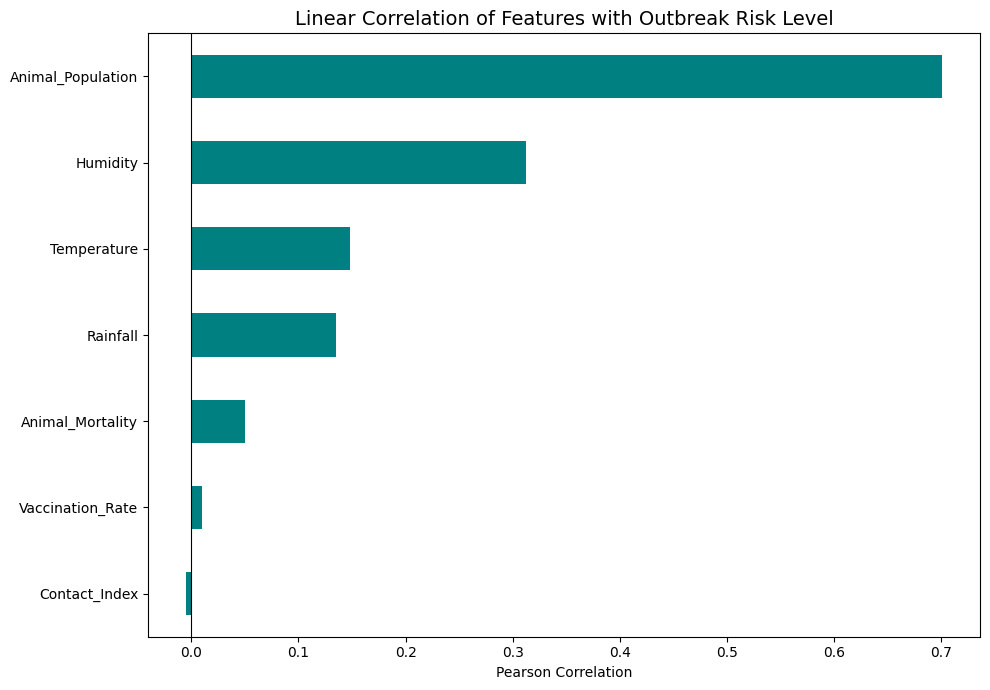

In [9]:
# =============================================================================
#  Feature importance proxy using simple correlation with target
# =============================================================================
correlations = df.corr(numeric_only=True)['Target'].sort_values(ascending=False)

print("\nFeature correlation with target (Target):")
print(correlations.round(3))

plt.figure(figsize=(10, 7))
correlations.drop("Target").sort_values().plot(kind='barh', color='teal')
plt.axvline(0, color='black', lw=0.8)
plt.title("Linear Correlation of Features with Outbreak Risk Level", fontsize=14)
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()



Outbreak risk is dominated by animal population, with humidity a strong secondary driver. Temperature and rainfall matter but less. Mortality adds limited signal. Vaccination rate and contact index contribute almost nothing linearly. This suggests risk is scale and environment driven, not behavior driven, in this dataset..

# **Sweetviz for Auto EDA**

In [10]:
import sweetviz as sv
import pandas as pd

report = sv.analyze(df)
report.show_html("sweetviz_full_report_farm.html")


c:\Users\dayav\anaconda3\envs\aienv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)


Report sweetviz_full_report_farm.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# Distribution of each column

Plotting 7 features with actual data (out of 7 numeric columns)
Valid features: ['Animal_Population', 'Animal_Mortality', 'Vaccination_Rate', 'Temperature', 'Humidity', 'Rainfall', 'Contact_Index']


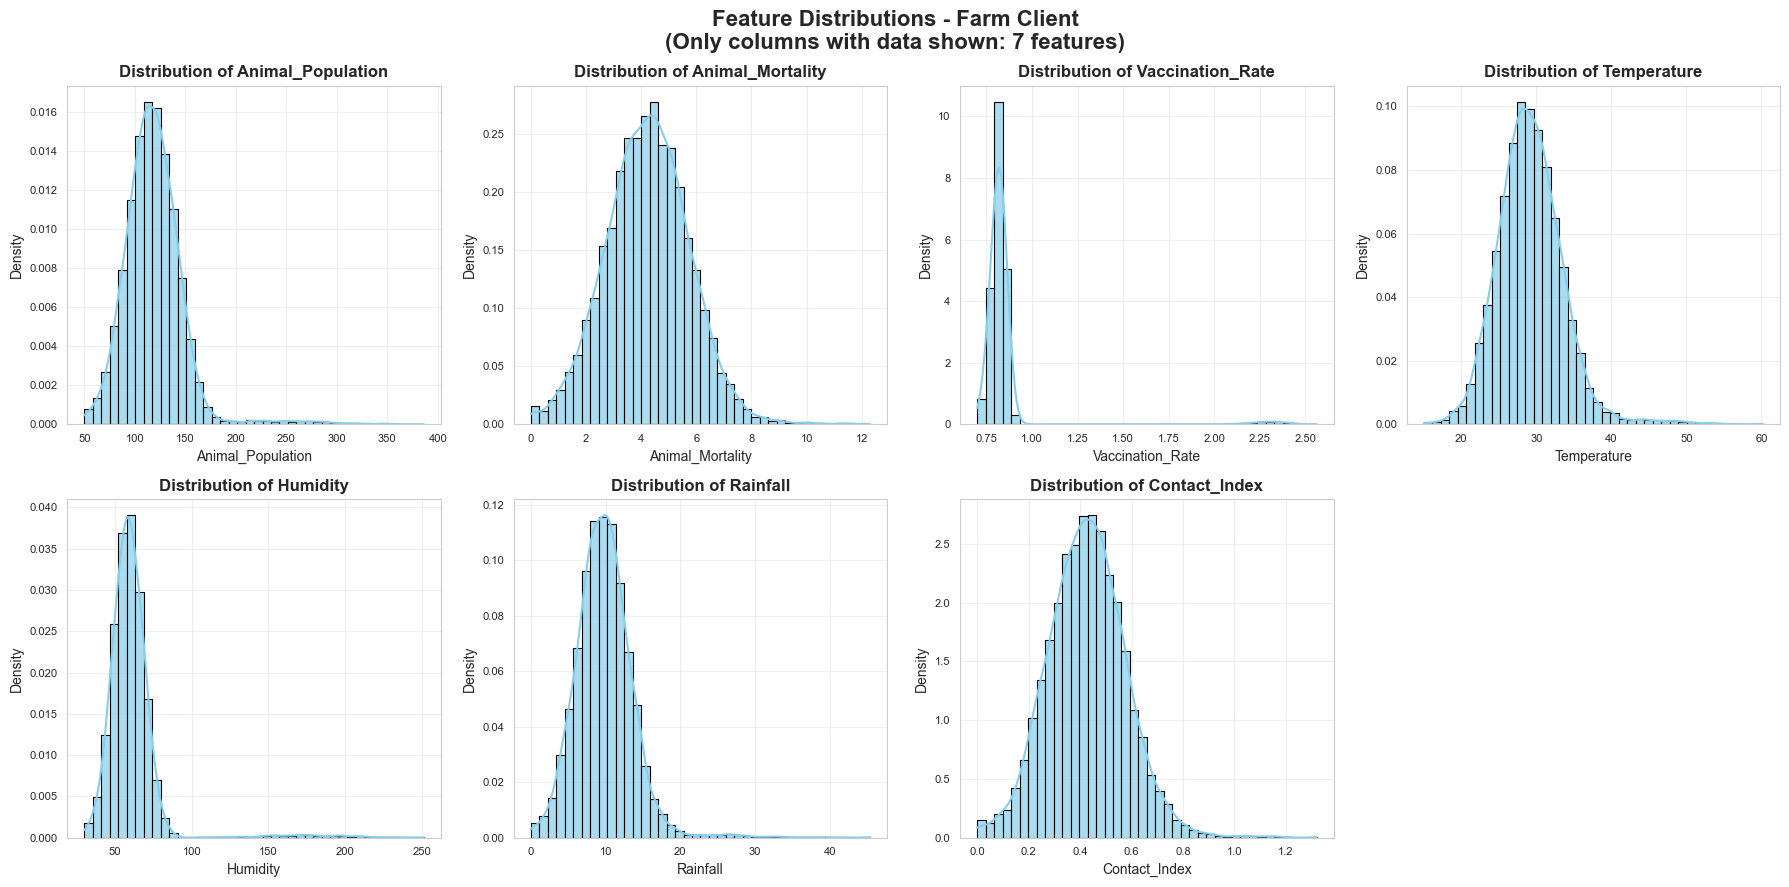

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: nicer style
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-pastel')  # safe to use


# Remove the target column from plotting
if 'Target' in df.columns:
    target_col = 'Target'
else:
    target_col = None

# Get numeric columns that are NOT completely empty (have at least one non-null value)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove target if present
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Keep only columns that have at least one real value (not fully NaN)
valid_cols = [col for col in numeric_cols if df[col].notna().any()]

print(f"Plotting {len(valid_cols)} features with actual data (out of {len(numeric_cols)} numeric columns)")
print("Valid features:", valid_cols)

# If no valid columns, stop early
if len(valid_cols) == 0:
    print("No features with data found to plot.")
else:
    # Grid setup
    n_cols_plot = min(4, len(valid_cols))  # max 4 per row
    n_rows = (len(valid_cols) + 3) // 4

    fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 4.5))
    axes = axes.flatten()

    for i, col in enumerate(valid_cols):
        sns.histplot(
            data=df[col], 
            kde=True,
            ax=axes[i],
            color='skyblue',
            edgecolor='black',
            alpha=0.7,
            bins=40,
            stat="density",
            linewidth=0.8
        )
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Density', fontsize=10)
        axes[i].grid(True, alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Main title
    plt.suptitle(f'Feature Distributions - Farm Client\n'
                 f'(Only columns with data shown: {len(valid_cols)} features)', 
                 fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout()
    plt.show()

Farm features show mostly smooth, near-normal distributions with mild right skew. Animal population, humidity, and rainfall have long tails, hinting at extreme conditions. Vaccination rate is tightly clustered, suggesting stability. Contact index is centered and symmetric, acting as a contextual exposure signal rather than a dominant risk driver.

## Qunatile- Quantile plot

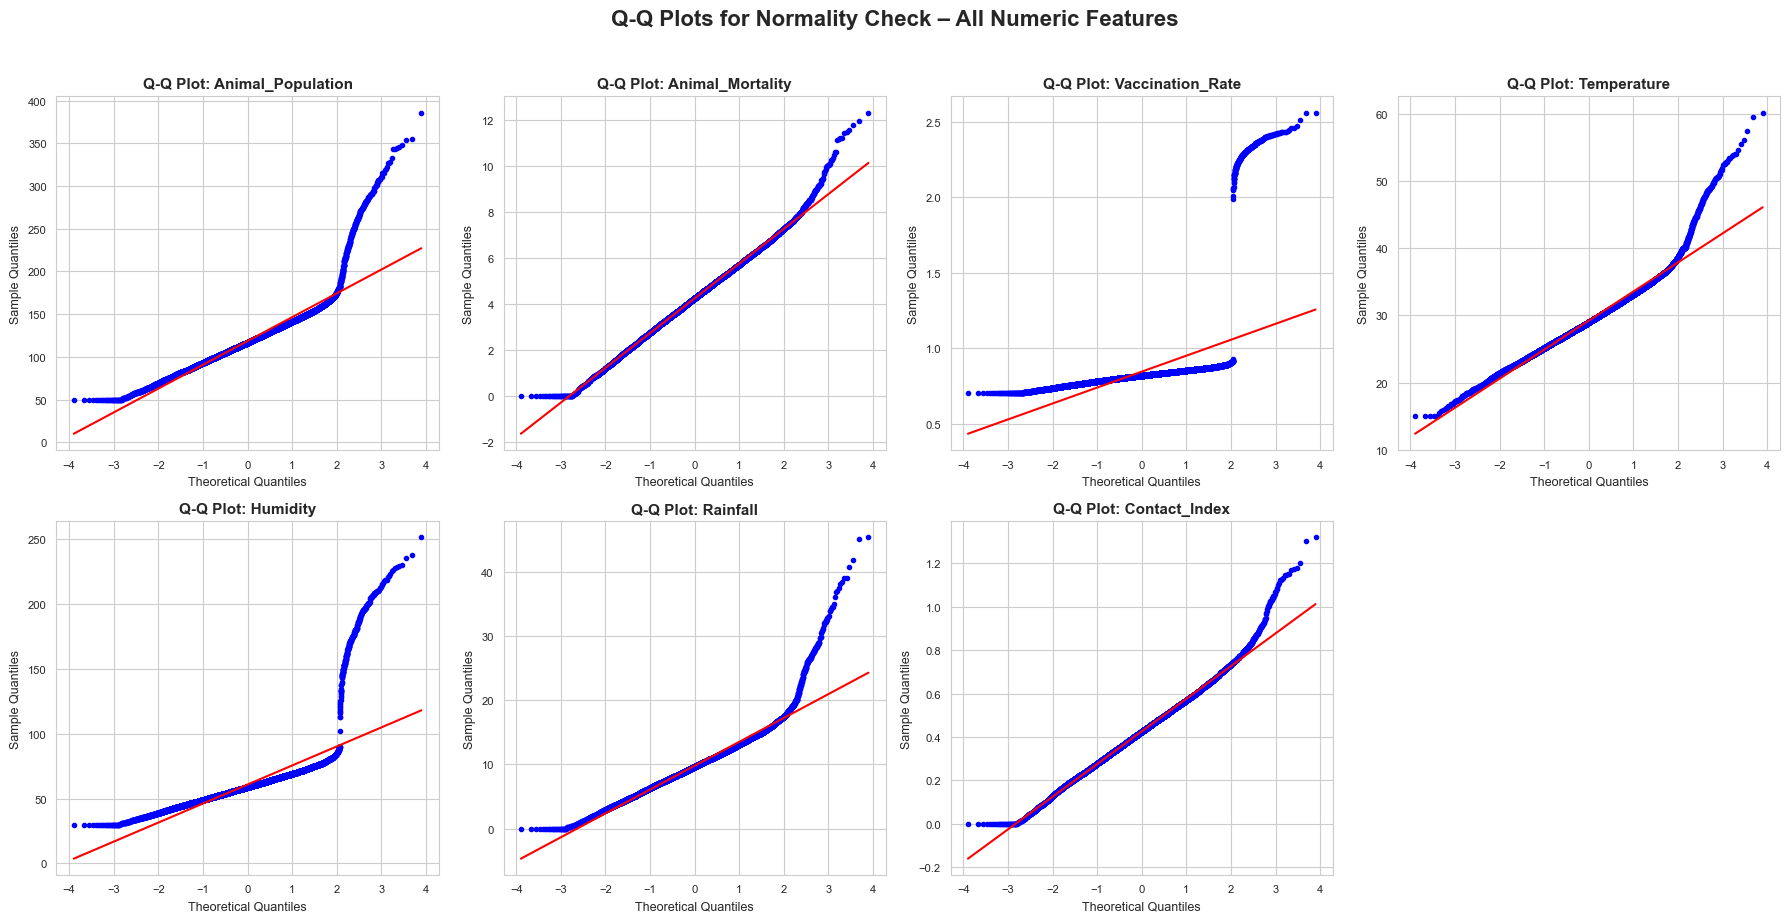

In [12]:
import scipy.stats as stats
sns.set_style("whitegrid")

# Get all numeric features (exclude target)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'Target' in numeric_cols:
    numeric_cols.remove('Target')

# Grid setup: 4 columns, auto rows
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Q-Q plot
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Theoretical Quantiles', fontsize=9)
    axes[i].set_ylabel('Sample Quantiles', fontsize=9)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots for Normality Check – All Numeric Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The Q–Q plots show most features deviate from perfect normality. Animal population, humidity, rainfall, and temperature display strong right tails, indicating skewness and extreme values. Animal mortality is closer to normal but still shows tail deviations. Vaccination rate is highly non-normal and truncated. Contact index aligns best with normality in the center but diverges at extremes. Overall, these distributions justify using robust scaling, tree-based models, or non-linear methods rather than assuming Gaussian behavior in downstream modeling.

## Scatter plot

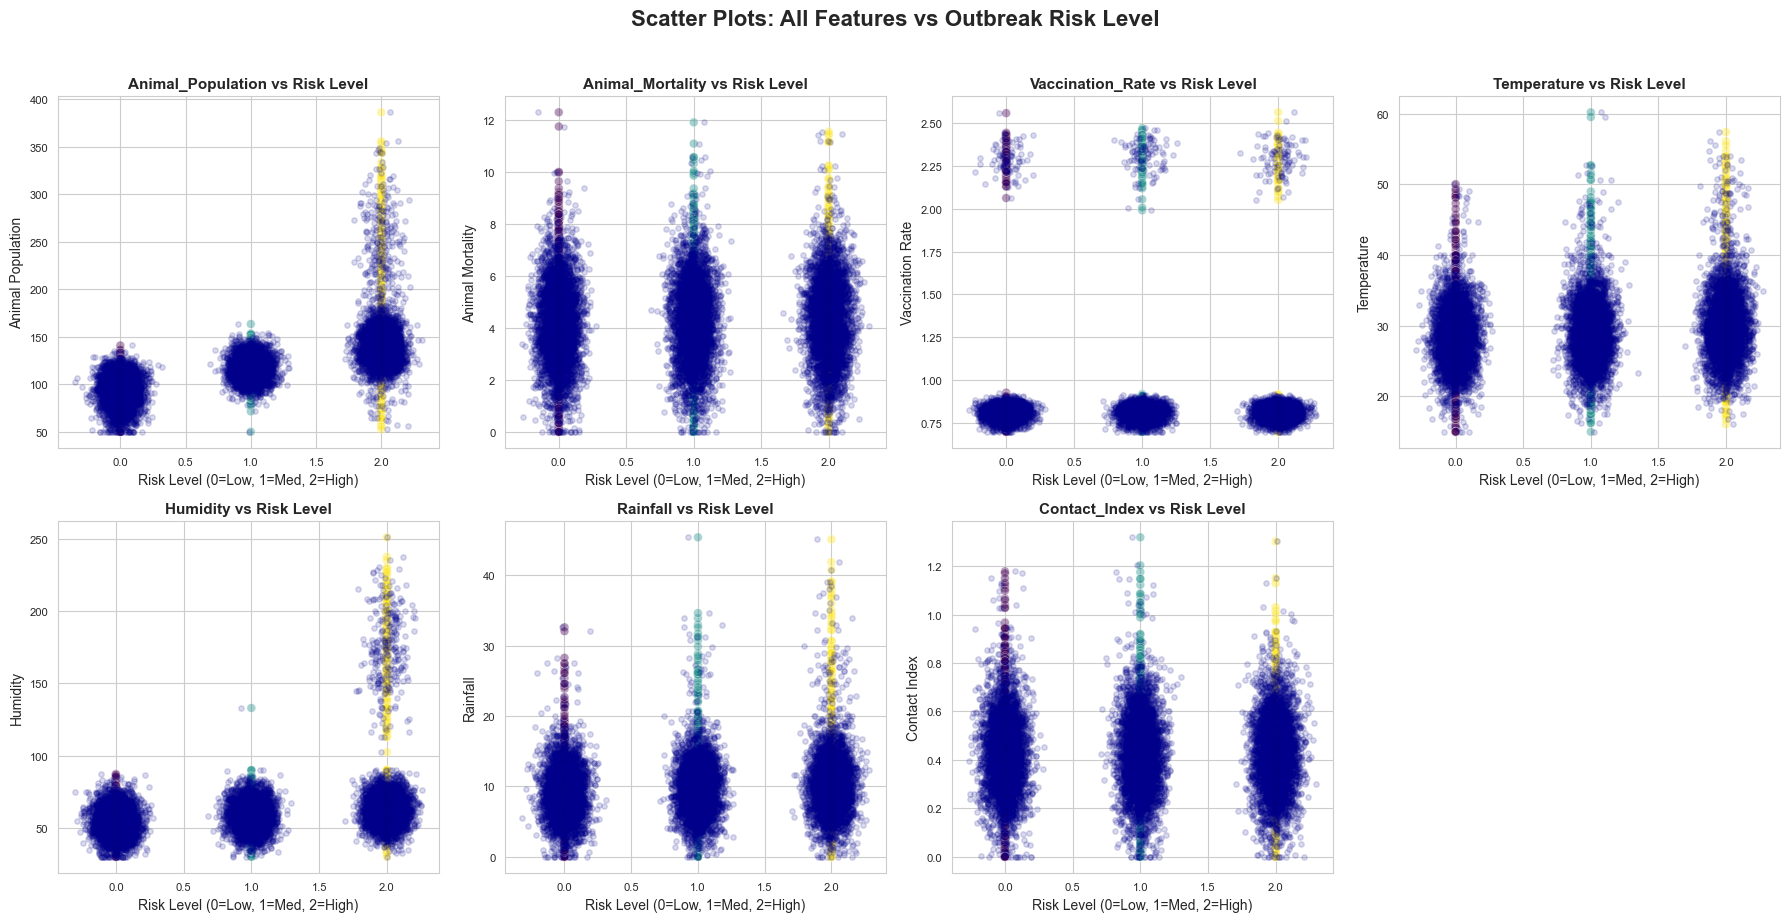

In [13]:
fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(
        x="Target",
        y=col,
        data=df,
        ax=axes[i],
        alpha=0.4,
        s=40,
        hue="Target",
        palette="viridis",
        legend=False
    )
    # Add small jitter to x-axis to better see density
    axes[i].scatter(
        df["Target"] + np.random.normal(0, 0.08, len(df)),
        df[col],
        alpha=0.15,
        s=15,
        color='darkblue'
    )
    axes[i].set_title(f'{col} vs Risk Level', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Risk Level (0=Low, 1=Med, 2=High)')
    axes[i].set_ylabel(col.replace('_', ' '), fontsize=10)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Scatter Plots: All Features vs Outbreak Risk Level',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Animal population shows the clearest separation across risk levels, increasing sharply from low to high risk. Humidity, temperature, and rainfall rise gradually with risk but overlap heavily. Mortality shows weak separation. Vaccination rate and contact index remain flat, offering little discriminatory power for outbreak risk classification.

# **`Final EDA Summary on farm Dataset`**
Outbreak risk in the farm client data is primarily driven by scale and environment. Animal population is the strongest predictor, showing clear separation across risk levels and the highest correlation with the target. Humidity, temperature, and rainfall contribute meaningfully, with higher values associated with increased risk, though with overlap.

Animal mortality provides limited additional signal and behaves closer to normal. Vaccination rate is stable and weakly related to risk, suggesting good coverage but low variability. Contact index remains largely uniform across classes, acting as contextual noise rather than a driver.

Overall, the data is non-normal, skewed, and influenced by extremes, favoring robust preprocessing and non-linear or tree-based models over linear assumptions.